# Detailed SentiWise Framework Demonstration
This notebook demonstrates each core function of the SentiWise framework, generating detailed outputs for each step.

In [ ]:
import sys
import os

sys.path.append(os.path.abspath('../src'))
from sentiwise.core.senti_data import SentiData

c:\Users\Swapnil\AppData\Local\Programs\Python\Python310\lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.0.6) or chardet (7.4.0.post1)/charset_normalizer (3.3.0) doesn't match a supported version!
  warnings.warn(
c:\Users\Swapnil\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Loading
Loading the dataset from CSV and viewing the first few rows. The `head()` function is used to peek at the data abstracting away pandas.

In [2]:
data = SentiData('../data/reviews_dataset_large.csv')
data.head(3)

[{'sr_no': 1,
  'id': 14,
  'timestamp': '2025-01-02T23:00:00.000',
  'content': 'please make this available in android ios alone is not enough',
  'location': 'NY',
  'category': 'Software'},
 {'sr_no': 2,
  'id': 54,
  'timestamp': '2025-01-05T16:00:00.000',
  'content': 'i demand a refund immediately i am never buying from this brand again honestly',
  'location': 'TX',
  'category': 'Retail'},
 {'sr_no': 3,
  'id': 62,
  'timestamp': '2025-01-05T21:00:00.000',
  'content': 'the package arrived on tuesday as expected honestly',
  'location': 'FL',
  'category': 'Retail'}]

## 2. Sentiment Analysis
Analyzing the sentiment (Positive, Neutral, Negative) for each review and viewing the overall distribution.

In [3]:
data.analyze_sentiment()
print("Sentiment Distribution:")
print(data.aggregate("sentiment"))

100%|██████████| 2/2 [00:04<00:00,  2.41s/it]

Sentiment Distribution:
{'negative': 0.42857142857142855, 'positive': 0.3968253968253968, 'neutral': 0.1746031746031746}


## 3. Topic Extraction
Extracting discussion topics from the dataset automatically using embeddings.

In [4]:
data.extract_topics(size=3)
data.head(2)

c:\Users\Swapnil\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Batches: 100%|██████████| 2/2 [00:00<00:00,  9.32it/s]


[{'sr_no': 1,
  'id': 14,
  'timestamp': '2025-01-02T23:00:00.000',
  'content': 'please make this available in android ios alone is not enough',
  'location': 'NY',
  'category': 'Software',
  'sentiment': 'neutral',
  'review_topic': 0,
  'topic': 'update'},
 {'sr_no': 2,
  'id': 54,
  'timestamp': '2025-01-05T16:00:00.000',
  'content': 'i demand a refund immediately i am never buying from this brand again honestly',
  'location': 'TX',
  'category': 'Retail',
  'sentiment': 'negative',
  'review_topic': 1,
  'topic': 'bought'}]

## 4. Topic Sentiment Matrix
Seeing how people feel about each specific topic.

In [5]:
matrix = data.topic_sentiment()
matrix


Topic Sentiment Matrix

{0: {'negative': 10, 'neutral': 9, 'positive': 15}, 1: {'negative': 11, 'neutral': 2, 'positive': 3}, 2: {'negative': 6, 'neutral': 0, 'positive': 7}}


{0: {'negative': 10, 'neutral': 9, 'positive': 15},
 1: {'negative': 11, 'neutral': 2, 'positive': 3},
 2: {'negative': 6, 'neutral': 0, 'positive': 7}}

## 5. Toxicity Detection
Identifying toxic or abusive comments in the dataset.

In [6]:
data.detect_toxicity()
print("Toxicity Flag Distribution:")
print(data.aggregate("is_toxic"))


Detecting Toxicity...


100%|██████████| 2/2 [00:01<00:00,  1.45it/s]

Toxicity Flag Distribution:
{False: 0.9523809523809523, True: 0.047619047619047616}


## 6. Named Entity Recognition (NER)
Extracting named entities such as companies, locations, and products mentioned in the text.

In [7]:
data.extract_ner()
data.head(2)

Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).



Extracting Named Entities...


100%|██████████| 63/63 [00:02<00:00, 23.93it/s]


[{'sr_no': 1,
  'id': 14,
  'timestamp': '2025-01-02T23:00:00.000',
  'content': 'please make this available in android ios alone is not enough',
  'location': 'NY',
  'category': 'Software',
  'sentiment': 'neutral',
  'review_topic': 0,
  'topic': 'update',
  'is_toxic': False,
  'named_entities': '[]'},
 {'sr_no': 2,
  'id': 54,
  'timestamp': '2025-01-05T16:00:00.000',
  'content': 'i demand a refund immediately i am never buying from this brand again honestly',
  'location': 'TX',
  'category': 'Retail',
  'sentiment': 'negative',
  'review_topic': 1,
  'topic': 'bought',
  'is_toxic': False,
  'named_entities': '[]'}]

## 7. Time-Series Analysis
Aggregating sentiment over time (e.g., Weekly) to track sentiment trends.

In [8]:
ts = data.time_series(freq="W")
print("Time Series Data (Weekly):\n", ts[:3])

Time Series Data (Weekly):
 [{'timestamp': Timestamp('2025-01-05 00:00:00'), 'sentiment_score': 0.0}, {'timestamp': Timestamp('2025-01-12 00:00:00'), 'sentiment_score': -0.2}, {'timestamp': Timestamp('2025-01-19 00:00:00'), 'sentiment_score': -0.5}]


## 8. Summarization
Summarizing individual reviews or topics. *(Note: requires Ollama to be running locally with the 'mistral' model).* Uncomment the code to run.

In [9]:
print("Single Review Summary:")
data.summarize(row=0)

print("\nTopic Summaries:")
data.topic_summary(model="mistral")

Single Review Summary:

Summary:

The review implies that availability on Android and iOS isn't sufficient for a suitable user experience.

Topic Summaries:

Topic 0
Summary: The review highlights issues with a mobile app, criticizing its battery life, requirement for iOS 14 or later, absence of advanced formatting features, and slow customer service. The user also praises the clean UI and fast performance but ultimately cancels their subscription due to these problems. Additionally, the user expresses satisfaction with switching from an iPhone to a Samsung Galaxy.

Topic 1
Summary: The customer demands a refund, expresses dissatisfaction towards the product (phone) and the brand, mentions that the phone did not come with a charger, states that they will buy from Best Buy instead in future, and compliments the food but criticizes the service at an unspecified location.

Topic 2
Summary: Two users are unhappy with recurring issues (bugs and broken zippers) and are threatening to switch 

{0: 'The review highlights issues with a mobile app, criticizing its battery life, requirement for iOS 14 or later, absence of advanced formatting features, and slow customer service. The user also praises the clean UI and fast performance but ultimately cancels their subscription due to these problems. Additionally, the user expresses satisfaction with switching from an iPhone to a Samsung Galaxy.',
 1: 'The customer demands a refund, expresses dissatisfaction towards the product (phone) and the brand, mentions that the phone did not come with a charger, states that they will buy from Best Buy instead in future, and compliments the food but criticizes the service at an unspecified location.',
 2: 'Two users are unhappy with recurring issues (bugs and broken zippers) and are threatening to switch to competitors unless problems are fixed. One user praises quick customer service.'}

## 9. Advanced Extraction (Intent, Emotion, ABSA, Sarcasm)
Using the advanced Ollama model for deep extraction of Aspect-Based Sentiment Analysis (ABSA), emotions, and sarcasm. *(Note: requires Ollama).* Uncomment the code to run.

In [10]:
data.extract_advanced(model="mistral")
data.head(2)


Running Super Extractor via Ollama (mistral)... This may take a few minutes for large datasets.


100%|██████████| 63/63 [05:22<00:00,  5.13s/it]


[{'sr_no': 1,
  'id': 14,
  'timestamp': '2025-01-02T23:00:00.000',
  'content': 'please make this available in android ios alone is not enough',
  'location': 'NY',
  'category': 'Software',
  'sentiment': 'neutral',
  'review_topic': 0,
  'topic': 'availability on Android',
  'is_toxic': False,
  'named_entities': '[]',
  'sentiment_score': 0,
  'emotion': 'anger',
  'intent': 'feature_request',
  'sarcasm': False,
  'absa': "[{'aspect': 'availability', 'sentiment': 'negative'}]"},
 {'sr_no': 2,
  'id': 54,
  'timestamp': '2025-01-05T16:00:00.000',
  'content': 'i demand a refund immediately i am never buying from this brand again honestly',
  'location': 'TX',
  'category': 'Retail',
  'sentiment': 'negative',
  'review_topic': 1,
  'topic': 'refund',
  'is_toxic': False,
  'named_entities': '[]',
  'sentiment_score': -1,
  'emotion': 'anger',
  'intent': 'complaint',
  'sarcasm': False,
  'absa': "[{'aspect': 'brand', 'sentiment': 'negative'}, {'aspect': 'purchase', 'sentiment': 'n

## 10. Visualization
Visualizing the sentiment distribution as a bar chart.

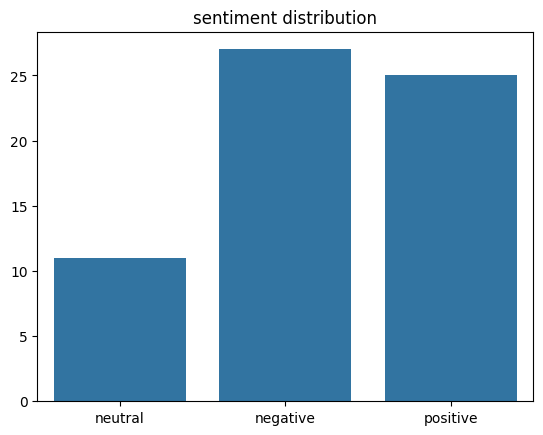

In [11]:
%matplotlib inline
data.visualize("bar", "sentiment")

## 11. Filtering by Columns
Filtering the dataset based on available metadata (e.g. category or location).

In [12]:
try:
    categories = [d.get('category') for d in data.head(5)]
    print("Categories in the first 5 rows:", categories)
    
    if categories and categories[0]:
        first_cat = categories[0]
        filtered_data = data.by_category(first_cat)
        print(f"\nTotal records for '{first_cat}':", len(filtered_data.data))
except Exception as e:
    print("Filtering not applicable or error:", e)

Categories in the first 5 rows: ['Software', 'Retail', 'Retail', 'Electronics', 'Software']

Total records for 'Software': 27


## 12. Result Export
Exporting the final enriched dataset to a new CSV file.

In [13]:
if not os.path.exists('../results'):
    os.makedirs('../results')

data.export('../results/sample2_results.csv')
print("Dataset successfully exported to results/sample2_results.csv")

Dataset successfully exported to results/sample2_results.csv
